<a href="https://colab.research.google.com/github/2303a52135-sai/AI-Assisted-Coding/blob/main/Parallel_RGB_Pixel_Extraction_Using_GPU_Acceleration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi


Fri Feb 13 07:47:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install numba


In [ ]:
!pip install numba


Saving file_00000000dac47230ba71ead927c3ef11.png to file_00000000dac47230ba71ead927c3ef11.png
Image Size: 1024 x 1536
Total Pixels: 1572864

GPU Processing Time: 1.6206 seconds
Average RGB Value: (92.04, 37.73, 31.82)


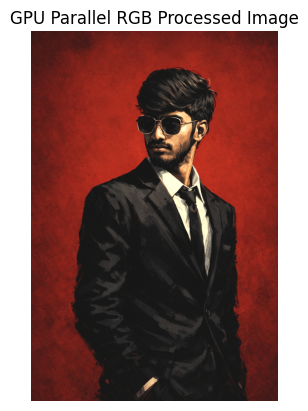

Streaming output truncated to the last 5000 lines.
Pixel (120,1531) → R=84 G=27 B=25
Pixel (121,1531) → R=83 G=25 B=22
Pixel (122,1531) → R=88 G=26 B=23
Pixel (123,1531) → R=92 G=28 B=25
Pixel (124,1531) → R=91 G=27 B=24
Pixel (125,1531) → R=85 G=22 B=20
Pixel (126,1531) → R=98 G=26 B=25
Pixel (127,1531) → R=113 G=35 B=29
Pixel (128,1531) → R=118 G=38 B=31
Pixel (129,1531) → R=108 G=30 B=26
Pixel (130,1531) → R=117 G=39 B=33
Pixel (131,1531) → R=107 G=33 B=28
Pixel (132,1531) → R=96 G=25 B=23
Pixel (133,1531) → R=97 G=26 B=22
Pixel (134,1531) → R=98 G=29 B=24
Pixel (135,1531) → R=93 G=25 B=22
Pixel (136,1531) → R=96 G=27 B=23
Pixel (137,1531) → R=112 G=37 B=31
Pixel (138,1531) → R=113 G=38 B=34
Pixel (139,1531) → R=94 G=27 B=24
Pixel (140,1531) → R=91 G=27 B=24
Pixel (141,1531) → R=91 G=28 B=24
Pixel (142,1531) → R=95 G=30 B=27
Pixel (143,1531) → R=88 G=23 B=22
Pixel (144,1531) → R=114 G=42 B=38
Pixel (145,1531) → R=110 G=40 B=35
Pixel (146,1531) → R=95 G=29 B=27
Pixel (147,1531) → R=8

In [ ]:
from google.colab import files
import numpy as np
import cv2
import matplotlib.pyplot as plt
from numba import cuda
import math
import time

# -------------------------------
# Upload Image (ONLY ONCE)
# -------------------------------
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# Read image
image = cv2.imread(filename)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = image.astype(np.uint8)

height, width, channels = image.shape

print("Image Size:", width, "x", height)
print("Total Pixels:", width * height)

# -------------------------------
# Allocate GPU Memory
# -------------------------------
d_input = cuda.to_device(image)
d_output = cuda.device_array_like(image)

# RGB sum for average calculation
rgb_sum = np.zeros(3, dtype=np.int64)
d_rgb_sum = cuda.to_device(rgb_sum)

# -------------------------------
# CUDA Kernel
# -------------------------------
@cuda.jit
def process_and_extract(input_img, output_img, rgb_total):

    x, y = cuda.grid(2)

    if x < input_img.shape[1] and y < input_img.shape[0]:

        r = input_img[y, x, 0]
        g = input_img[y, x, 1]
        b = input_img[y, x, 2]

        # Brightness boost
        r = min(r + 20, 255)
        g = min(g + 20, 255)
        b = min(b + 20, 255)

        output_img[y, x, 0] = r
        output_img[y, x, 1] = g
        output_img[y, x, 2] = b

        # Atomic add for average RGB
        cuda.atomic.add(rgb_total, 0, r)
        cuda.atomic.add(rgb_total, 1, g)
        cuda.atomic.add(rgb_total, 2, b)

# -------------------------------
# Launch Kernel
# -------------------------------
threads = (16, 16)
blocks = (math.ceil(width/16), math.ceil(height/16))

start = time.time()

process_and_extract[blocks, threads](d_input, d_output, d_rgb_sum)
cuda.synchronize()

end = time.time()

# -------------------------------
# Copy Results Back
# -------------------------------
result = d_output.copy_to_host()
rgb_sum_result = d_rgb_sum.copy_to_host()

# -------------------------------
# Compute Average RGB
# -------------------------------
total_pixels = width * height
avg_r = rgb_sum_result[0] / total_pixels
avg_g = rgb_sum_result[1] / total_pixels
avg_b = rgb_sum_result[2] / total_pixels

print("\nGPU Processing Time:", round(end - start, 4), "seconds")
print("Average RGB Value: (%.2f, %.2f, %.2f)" % (avg_r, avg_g, avg_b))

# -------------------------------
# Display Processed Image
# -------------------------------
plt.imshow(result)
plt.title("GPU Parallel RGB Processed Image")
plt.axis("off")
plt.show()

# -------------------------------
# PRINT RGB VALUE OF EACH PIXEL
# -------------------------------

print("\n--- RGB Values of Each Pixel ---\n")

for y in range(height):
    for x in range(width):
        r = result[y, x, 0]
        g = result[y, x, 1]
        b = result[y, x, 2]
        print(f"Pixel ({x},{y}) → R={r} G={g} B={b}")
